# 01 — Build Fingerprint Database
## MR Localization via Radio Fingerprinting

**Purpose.** This notebook constitutes Module 1 (M1) of the localization pipeline. It consumes `measurement_data_train.parquet` — the training-split records produced by M0 (`00_eda.ipynb`) — and constructs the fingerprint database (`fp_db.parquet`) that M2 uses at inference time.

**Method.** Each unique `(sim_x, sim_y)` position in the training records becomes one row in the fingerprint DB. The 26 cell RSRP values are pivoted to wide format and averaged across UEs that visited the same grid point. Cells not measured at a position are filled with −120 dBm (noise floor), as justified in M0.

**Inputs.**

| File | Source | Description |
|---|---|---|
| `data/processed/measurement_data_train.parquet` | M0 | Cleaned, training-split long-format records |

**Notebook structure.**

| Section | Topic |
|---|---|
| §1 | Load Inputs |
| §2 | Fingerprint Database Construction |
| §3 | Sparsity Analysis |
| §4 | Save Output |

**Output.** `data/processed/fp_db.parquet` — one row per unique `(sim_x, sim_y)` in the training set, with 26 RSRP feature columns.

## 0. Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

PROCESSED_DIR  = '../data/processed'
TRAIN_PATH     = f'{PROCESSED_DIR}/measurement_data_train.parquet'
FILL_VAL       = -120.0

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs('../results', exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Inputs

Load `measurement_data_train.parquet` and verify its structure. The training set was produced by M0 using `GroupShuffleSplit(test_size=0.2, random_state=42, groups=ue_id)` — it contains ~80% of UEs and excludes any UE that appears in the test set.

| Variable | Description |
|---|---|
| `train_df` | Long-format training records: `ue_id`, `sim_x`, `sim_y`, `date`, `rsrp`, `gcell_id`, `ue_height` |

In [2]:
train_df = pd.read_parquet(TRAIN_PATH)

print(f'Training records : {len(train_df):,} rows x {train_df.shape[1]} columns')
print(f'Unique UEs       : {train_df["ue_id"].nunique():,}')
print(f'Unique positions : {train_df.groupby(["sim_x", "sim_y"]).ngroups:,}')
print(f'RSRP range       : [{train_df["rsrp"].min():.1f}, {train_df["rsrp"].max():.1f}] dBm')
train_df.head(3)

Training records : 34,022 rows x 7 columns
Unique UEs       : 1,192
Unique positions : 6,746
RSRP range       : [-116.0, -42.0] dBm


,ue_id,sim_x,sim_y,date,rsrp,gcell_id,ue_height
0,e3d3e5fb61d454ce8fc44cc8b94b0723,-126.868,-390.476,2026-03-18 19:38:15.729000+00:00,-82.000,296382a9c48359978b4c4433a81194a1,0.500
1,e3d3e5fb61d454ce8fc44cc8b94b0723,-110.056,-343.944,2026-03-18 19:38:15.729000+00:00,-82.000,296382a9c48359978b4c4433a81194a1,0.500
2,e3d3e5fb61d454ce8fc44cc8b94b0723,-66.343,-293.833,2026-03-18 19:38:15.729000+00:00,-82.000,296382a9c48359978b4c4433a81194a1,0.500


## 2. Fingerprint Database Construction

Pivot the long-format training records to wide format:
1. Group by `(sim_x, sim_y, gcell_id)` and aggregate RSRP with `mean`
2. Unstack `gcell_id` as column axis — each column is one cell's RSRP
3. Fill missing values (cells not measured at a position) with `−120.0` dBm

The resulting `fp_db` has shape `(n_train_positions, 28)` — two coordinate columns plus 26 RSRP features.

| Variable | Shape | Description |
|---|---|---|
| `fp_db` | (n_pos, 28) | Fingerprint DB: `sim_x`, `sim_y`, + 26 cell RSRP columns |
| `cell_cols` | list[str] | The 26 cell column names |
| `X_fp` | (n_pos, 26) | Feature matrix for WKNN fitting |
| `y_fp` | (n_pos, 2) | Position targets `[sim_x, sim_y]` |

In [3]:
fp_db = (train_df
         .groupby(['sim_x', 'sim_y', 'gcell_id'])['rsrp']
         .mean()
         .unstack('gcell_id')
         .reset_index()
         .fillna(FILL_VAL))

cell_cols = [c for c in fp_db.columns if c not in ['sim_x', 'sim_y']]
X_fp      = fp_db[cell_cols].values
y_fp      = fp_db[['sim_x', 'sim_y']].values

print(f'Fingerprint DB shape : {fp_db.shape}  '
      f'({len(fp_db)} positions x {len(cell_cols)} cell features + 2 coord cols)')
print(f'X_fp shape           : {X_fp.shape}')
print(f'y_fp shape           : {y_fp.shape}')
fp_db.head(3)

Fingerprint DB shape : (6746, 28)  (6746 positions x 26 cell features + 2 coord cols)
X_fp shape           : (6746, 26)
y_fp shape           : (6746, 2)


gcell_id,sim_x,sim_y,11c1123252b25623b7e5207748622c90,1a37b9890d8a5c65bc79dc4a2c682c83,23e944ebe39d5cc7a5c0e0df00aa88a2,296382a9c48359978b4c4433a81194a1,31c961ef3add553789472d3c8f142b8c,3337aca2dd005dbcb9fed33e0efdd782,4073ada86ca45553ba5562b54774ac68,445260e4d9e85a409ff8637aed4a0fb0,501e096c79935948827a714a65bee215,66702486da695d48a32870fb5a19f034,6993510be036564ab71261ec2163f3dd,834235bb062451c485a85cec608a6e05,95398adec8c8578c82a432c9d1a750d0,95d90fddc9205d0f916a9fd9584fddaf,a0fe30c12f7c5ab7b23221f84d4ead1a,b01a463a209e553b80729fa497d38f7e,bdb144be0d005f64a1735f9b7731ee22,c26c46348f915ba18aec76b2e439dbb3,d275ae93ac7d532f96c54d66f47d0a61,dbf2765943bd56b3b969e78978d15cd3,e7a3c45c21c7515485cc0990e347d9d5,e81fceee2e165bc8acadbb07a87e405e,f397c880c61e51ca99611a717fcdd7ab,f54c4e3c4b8c557fa19dc11b5cf7e1de,f72df7a384025ca989d0b74584e032e0,fb6b392b3d8b5d7fbea29d9012028a51
0,-4095.056,-3232.158,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-102.000,-120.000,-120.000,-120.000
1,-3919.480,1265.283,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-82.000,-120.000,-120.000,-120.000,-120.000
2,-3845.535,1105.990,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-120.000,-102.000,-120.000,-120.000,-120.000,-120.000


## 3. Sparsity Analysis

Quantify the fill ratio and per-cell spatial coverage to confirm the database matches the expected sparsity structure characterised in M0.

Fill entries (−120 dBm) : 159,267 / 175,396  (90.8%)
Observed entries        : 16,129  (9.2%)

Mean per-cell coverage : 9.2%
Min coverage           : 2.0%
Max coverage           : 24.6%


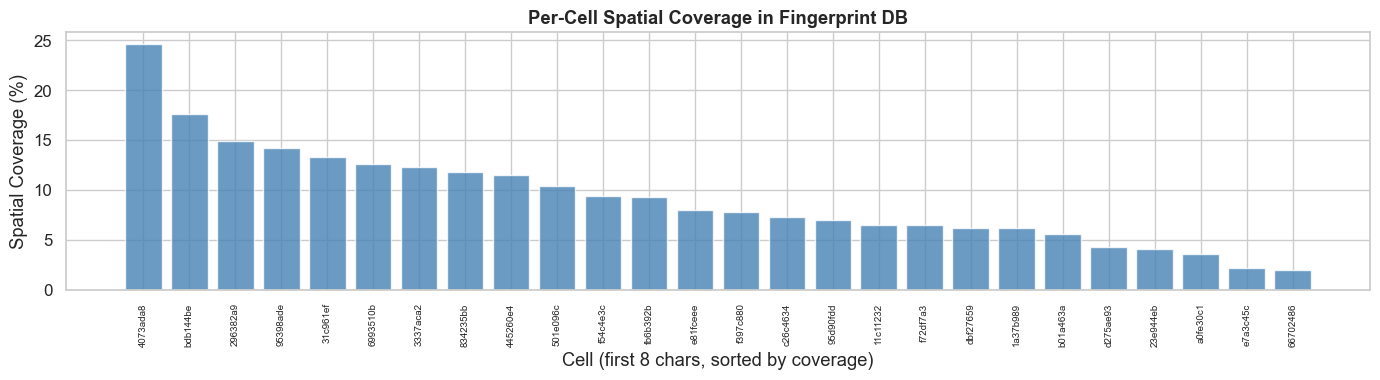

In [4]:
n_filled  = (X_fp == FILL_VAL).sum()
n_total   = X_fp.size
sparsity  = n_filled / n_total * 100
print(f'Fill entries (−120 dBm) : {n_filled:,} / {n_total:,}  ({sparsity:.1f}%)')
print(f'Observed entries        : {n_total - n_filled:,}  ({100 - sparsity:.1f}%)')

# Per-cell coverage
cell_coverage = (pd.Series((X_fp > FILL_VAL).mean(axis=0) * 100, index=cell_cols, name='coverage_%')
                 .sort_values(ascending=False))
print(f'\nMean per-cell coverage : {cell_coverage.mean():.1f}%')
print(f'Min coverage           : {cell_coverage.min():.1f}%')
print(f'Max coverage           : {cell_coverage.max():.1f}%')

# Quick bar chart
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(cell_cols)), cell_coverage.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(cell_cols)))
ax.set_xticklabels([c[:8] for c in cell_coverage.index], rotation=90, fontsize=7)
ax.set_xlabel('Cell (first 8 chars, sorted by coverage)')
ax.set_ylabel('Spatial Coverage (%)')
ax.set_title('Per-Cell Spatial Coverage in Fingerprint DB', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/fp_db_cell_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Save Output

Persist `fp_db` to `data/processed/fp_db.parquet` for consumption by M2 (`02_localize_mr.ipynb`).

In [5]:
fp_db_path = f'{PROCESSED_DIR}/fp_db.parquet'
fp_db.to_parquet(fp_db_path, index=False)
print(f'Saved fp_db -> {fp_db_path}  ({fp_db.shape[0]:,} positions x {fp_db.shape[1]} cols)')
print(f'Cell columns: {cell_cols}')

Saved fp_db -> ../data/processed/fp_db.parquet  (6,746 positions x 28 cols)
Cell columns: ['11c1123252b25623b7e5207748622c90', '1a37b9890d8a5c65bc79dc4a2c682c83', '23e944ebe39d5cc7a5c0e0df00aa88a2', '296382a9c48359978b4c4433a81194a1', '31c961ef3add553789472d3c8f142b8c', '3337aca2dd005dbcb9fed33e0efdd782', '4073ada86ca45553ba5562b54774ac68', '445260e4d9e85a409ff8637aed4a0fb0', '501e096c79935948827a714a65bee215', '66702486da695d48a32870fb5a19f034', '6993510be036564ab71261ec2163f3dd', '834235bb062451c485a85cec608a6e05', '95398adec8c8578c82a432c9d1a750d0', '95d90fddc9205d0f916a9fd9584fddaf', 'a0fe30c12f7c5ab7b23221f84d4ead1a', 'b01a463a209e553b80729fa497d38f7e', 'bdb144be0d005f64a1735f9b7731ee22', 'c26c46348f915ba18aec76b2e439dbb3', 'd275ae93ac7d532f96c54d66f47d0a61', 'dbf2765943bd56b3b969e78978d15cd3', 'e7a3c45c21c7515485cc0990e347d9d5', 'e81fceee2e165bc8acadbb07a87e405e', 'f397c880c61e51ca99611a717fcdd7ab', 'f54c4e3c4b8c557fa19dc11b5cf7e1de', 'f72df7a384025ca989d0b74584e032e0', 'fb6b392b